# 08 — Modelo com Mapa Manual de Conceitos

## Objetivo

Testar um primeiro mapa manual pequeno de `conceito_alarme` e `familia_alarme`, construído a partir
dos achados dos notebooks 06 e 07.

## Limite metodológico

Este é um experimento de desenvolvimento. Como os candidatos foram orientados por auditorias dos
erros já observados, inclusive no teste de junho, os resultados deste notebook não devem ser tratados
como validação final independente. A utilidade aqui é medir se o mapa manual reduz falsos positivos,
preserva recall e organiza melhor os alarmes para a próxima rodada.

Para validação final, será necessário congelar o mapa e avaliar em novo período, novo holdout ou
validação temporal posterior.

In [1]:
from pathlib import Path
import re
import time
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score, fbeta_score,
    precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

SEQUENCE_GAP_SECONDS = 60
TOP_ALARM_IDS = 200
TOP_TEXT_CONCEPTS = 200
TOP_MANUAL_CONCEPTS = 120
TOP_MANUAL_FAMILIES = 60
MISSING_DAY = pd.Timestamp("2025-05-31")
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

def normalize_alarm_name(value):
    if pd.isna(value):
        return "SEM_DESCRICAO"
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or "SEM_DESCRICAO"

def manual_concept_family(text):
    t = normalize_alarm_name(text)

    if t.startswith("OEM INTERFACE"):
        return "OEM_INTERFACE", "COMUNICACAO_INTERFACE"
    if t.startswith("RX CHANNEL") and "NOT RECEIVING MESSAGES" in t:
        return "RX_CHANNEL_SEM_MENSAGEM", "COMUNICACAO_INTERFACE"
    if "TIRE TAG TIMEOUT" in t:
        return "TIRE_TAG_TIMEOUT", "PNEUS_MONITORAMENTO"

    if t in {"DIPPER", "CYCLE", "BODY UP", "LOAD"}:
        return f"CICLO_{t.replace(' ', '_')}", "OPERACAO_CARGA_BASCULAMENTO"
    if "PAYLOAD OVERLOAD" in t:
        return "PAYLOAD_OVERLOAD", "OPERACAO_CARGA_BASCULAMENTO"
    if "TRUCK LOAD WEIGHT" in t or "BUCKET LOAD WEIGHT" in t:
        return "LOAD_WEIGHT", "OPERACAO_CARGA_BASCULAMENTO"
    if "BUCKET ANGLE" in t:
        return "BUCKET_ANGLE", "OPERACAO_CARGA_BASCULAMENTO"
    if "HOIST" in t or "LIFT ARMS" in t or "DUMP WHEEL" in t or "ROLLBACK" in t:
        return "LIMITE_MOVIMENTO_CARGA", "OPERACAO_CARGA_BASCULAMENTO"

    if "COOLANT LEVEL" in t or "ARREF" in t:
        return "ARREFECIMENTO_MOTOR", "MOTOR_ARREFECIMENTO"
    if "ENGINE PRELUBE" in t or "OLEO MOTOR" in t:
        return "LUBRIFICACAO_MOTOR", "MOTOR_LUBRIFICACAO"
    if "ENGINE AT HIGH THROTTLE" in t or "ENGINE AT LOW THROTTLE" in t:
        return "REGIME_MOTOR", "MOTOR_OPERACAO"
    if "EXHAUST TEMPERATURE" in t or "TEMP EXAUST" in t:
        return "TEMPERATURA_ESCAPE", "MOTOR_OPERACAO"

    if "PARKING BRAKE" in t or "FREIO" in t or "BRAKE" in t:
        return "SISTEMA_FREIO", "FREIOS"
    if "STEERING" in t or "DIRECAO" in t or "STEER" in t:
        return "SISTEMA_DIRECAO", "DIRECAO"
    if "TRANSMISSION OIL" in t or "DIFFERENTIAL" in t or "FINAL DRIVE" in t:
        return "TREM_FORCA_OLEO_FILTRO", "TREM_FORCA"
    if "SYSTEM VOLTAGE" in t or "VOLTAGE" in t or "VOLTAGEM" in t or "BATTERY" in t:
        return "SISTEMA_ELETRICO_TENSAO", "ELETRICO"
    if "VEHICLE SPEED" in t or "LIMITE DE VELOCIDADE" in t:
        return "VELOCIDADE_EQUIPAMENTO", "OPERACAO_VELOCIDADE"
    if "TESTE OP ENTRADA" in t:
        return "TESTE_OP_ENTRADA", "TESTE_OPERACIONAL"

    return t, "OUTROS"

print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: /home/f_szekut/projects/vale_correct


## 1. Reconstituição da base congelada

In [2]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE alarm_sequences AS
    WITH ordered AS (
        SELECT *,
               lag(Data_Evento) OVER (
                   PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
               ) AS evento_anterior
        FROM analytic_events
    ), flagged AS (
        SELECT *,
               CASE
                   WHEN evento_anterior IS NULL THEN 1
                   WHEN date_diff('millisecond', evento_anterior, Data_Evento)
                        > {SEQUENCE_GAP_SECONDS * 1000} THEN 1
                   ELSE 0
               END AS nova_sequencia
        FROM ordered
    ), numbered AS (
        SELECT *,
               sum(nova_sequencia) OVER (
                   PARTITION BY TAG, Id_Alarme
                   ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
               ) AS numero_sequencia
        FROM flagged
    )
    SELECT
        TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
        Id_Alarme, any_value(Alarme) AS Alarme,
        numero_sequencia,
        min(Data_Evento) AS inicio,
        max(Data_Evento) AS fim,
        date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo) AS registros_brutos_representados,
        max(Is_Dont_Go) AS is_dont_go,
        max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
        max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
        max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
        max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
    FROM numbered
    GROUP BY TAG, Id_Alarme, numero_sequencia
    '''
)

base_audit = query(
    '''
    SELECT
        (SELECT count(*) FROM analytic_events) AS registros_analiticos,
        (SELECT sum(ids_evento_no_grupo - 1) FROM analytic_events) AS duplicatas_retiradas,
        (SELECT sum(Is_Dont_Go) FROM analytic_events) AS linhas_dont_go,
        (SELECT count(*) FROM alarm_sequences) AS sequencias,
        (SELECT sum(is_dont_go) FROM alarm_sequences) AS sequencias_dont_go
    '''
)
base_audit["tempo_s"] = round(time.time() - start, 1)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,sequencias,sequencias_dont_go,tempo_s
0,35608094,265564.0,19941.0,4303625,14612.0,89.4


## 2. Catálogo manual inicial

In [3]:
alarm_catalog = query(
    '''
    SELECT Id_Alarme, any_value(Alarme) AS Alarme, count(*) AS sequencias, sum(is_dont_go) AS sequencias_dont_go
    FROM alarm_sequences
    GROUP BY 1
    ORDER BY sequencias DESC
    '''
)
alarm_catalog["conceito_textual"] = alarm_catalog["Alarme"].map(normalize_alarm_name)
manual = alarm_catalog["Alarme"].map(manual_concept_family)
alarm_catalog["conceito_manual"] = [x[0] for x in manual]
alarm_catalog["familia_manual"] = [x[1] for x in manual]

manual_audit = (
    alarm_catalog.groupby(["familia_manual", "conceito_manual"])
    .agg(
        ids=("Id_Alarme", "nunique"),
        sequencias=("sequencias", "sum"),
        sequencias_dont_go=("sequencias_dont_go", "sum"),
        exemplos=("Alarme", lambda x: " | ".join(sorted(set(map(str, x)))[:4])),
    )
    .reset_index()
    .sort_values(["sequencias_dont_go", "sequencias"], ascending=False)
)
display(manual_audit.head(80))
display(
    alarm_catalog.groupby("familia_manual")
    .agg(ids=("Id_Alarme", "nunique"), sequencias=("sequencias", "sum"), sequencias_dont_go=("sequencias_dont_go", "sum"))
    .reset_index()
    .sort_values("sequencias_dont_go", ascending=False)
)
con.register("alarm_concepts", alarm_catalog[["Id_Alarme", "conceito_textual", "conceito_manual", "familia_manual"]])

,familia_manual,conceito_manual,ids,sequencias,sequencias_dont_go,exemplos
5,MOTOR_ARREFECIMENTO,ARREFECIMENTO_MOTOR,26,47245,6215.0,Engine Coolant Level - Active | Engine Coolant...
4,FREIOS,SISTEMA_FREIO,233,65060,4614.0,Brake Coolant Pump Solenoid - Active | Brake C...
438,TREM_FORCA,TREM_FORCA_OLEO_FILTRO,18,95710,1415.0,Differential Filter Switch - Active | Differen...
67,OUTROS,AFTERCOOLER LEVEL ACTIVE,3,1559,792.0,Aftercooler Level - Active
2,DIRECAO,SISTEMA_DIRECAO,35,309689,524.0,Auxiliary Steering System Fault (L-1850) | Hig...
8,MOTOR_OPERACAO,TEMPERATURA_ESCAPE,39,15675,312.0,Left Exhaust Temperature - Active | Left Exhau...
122,OUTROS,CRANKCASE PRESSURE ACTIVE,3,534,228.0,Crankcase Pressure - Active
223,OUTROS,HYDRAULIC RESERVOIR OIL TEMPERATURE CRITICALLY...,1,156,152.0,Hydraulic Reservoir Oil Temperature Critically...
153,OUTROS,ENGINE OIL FILTER ACTIVE,2,141,141.0,Engine Oil Filter - Active
141,OUTROS,ENGINE COOLANT FLOW ACTIVE,2,122,122.0,Engine Coolant Flow - Active


,familia_manual,ids,sequencias,sequencias_dont_go
4,MOTOR_ARREFECIMENTO,26,47245,6215.0
3,FREIOS,233,65060,4614.0
9,OUTROS,645,631450,1532.0
12,TREM_FORCA,18,95710,1415.0
1,DIRECAO,35,309689,524.0
6,MOTOR_OPERACAO,42,58716,312.0
0,COMUNICACAO_INTERFACE,10,723677,0.0
2,ELETRICO,74,24593,0.0
5,MOTOR_LUBRIFICACAO,128,27384,0.0
8,OPERACAO_VELOCIDADE,17,96777,0.0


## 3. Janelas e features

In [4]:
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sequence_bins AS
    SELECT
        TAG,
        time_bucket(INTERVAL '8 hours', inicio) AS bin_start,
        count(*) AS sequencias_total,
        count(DISTINCT Id_Alarme) AS alarmes_distintos,
        sum(registros_analiticos) AS registros_analiticos,
        sum(registros_brutos_representados) AS registros_brutos_representados,
        avg(duracao_ms) AS duracao_media_ms,
        max(duracao_ms) AS duracao_max_ms,
        max(registros_analiticos) AS maior_sequencia_registros,
        sum(possui_critico) AS sequencias_com_critico,
        sum(possui_activate) AS sequencias_com_activate,
        sum(possui_inactive) AS sequencias_com_inactive,
        sum(possui_classe_nula) AS sequencias_com_classe_nula,
        sum(is_dont_go) AS episodios_dont_go
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)

con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sample_grid AS
    WITH tags AS (
        SELECT DISTINCT TAG FROM analytic_events
    ), feature_bins AS (
        SELECT * FROM generate_series(
            TIMESTAMP '2025-01-01 00:00:00',
            TIMESTAMP '2025-06-30 08:00:00',
            INTERVAL '8 hours'
        ) AS t(feature_start)
    )
    SELECT
        tags.TAG,
        feature_start,
        feature_start + INTERVAL '8 hours' AS prediction_time,
        feature_start + INTERVAL '16 hours' AS target_end
    FROM tags CROSS JOIN feature_bins
    '''
)

samples = query(
    f'''
    SELECT
        g.TAG, g.feature_start, g.prediction_time, g.target_end,
        coalesce(f.sequencias_total, 0) AS sequencias_total,
        coalesce(f.alarmes_distintos, 0) AS alarmes_distintos,
        coalesce(f.registros_analiticos, 0) AS registros_analiticos,
        coalesce(f.registros_brutos_representados, 0) AS registros_brutos_representados,
        coalesce(f.duracao_media_ms, 0) AS duracao_media_ms,
        coalesce(f.duracao_max_ms, 0) AS duracao_max_ms,
        coalesce(f.maior_sequencia_registros, 0) AS maior_sequencia_registros,
        coalesce(f.sequencias_com_critico, 0) AS sequencias_com_critico,
        coalesce(f.sequencias_com_activate, 0) AS sequencias_com_activate,
        coalesce(f.sequencias_com_inactive, 0) AS sequencias_com_inactive,
        coalesce(f.sequencias_com_classe_nula, 0) AS sequencias_com_classe_nula,
        coalesce(y.episodios_dont_go, 0) AS episodios_dont_go_target,
        CASE WHEN coalesce(y.episodios_dont_go, 0) > 0 THEN 1 ELSE 0 END AS target,
        CASE
            WHEN CAST(g.feature_start AS DATE) = DATE '{MISSING_DAY.date()}'
              OR CAST(g.prediction_time AS DATE) = DATE '{MISSING_DAY.date()}'
            THEN 0 ELSE 1
        END AS amostra_valida
    FROM sample_grid g
    LEFT JOIN sequence_bins f
      ON g.TAG = f.TAG AND g.feature_start = f.bin_start
    LEFT JOIN sequence_bins y
      ON g.TAG = y.TAG AND g.prediction_time = y.bin_start
    ORDER BY g.prediction_time, g.TAG
    '''
)
samples = samples[samples["amostra_valida"] == 1].copy()

tag_profile = query(
    '''
    SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
    FROM analytic_events
    GROUP BY 1
    '''
)
samples = samples.merge(tag_profile, how="left", on="TAG")
samples = samples.assign(split=np.select(
    [
        samples["prediction_time"] < pd.Timestamp("2025-05-01"),
        samples["prediction_time"] < pd.Timestamp("2025-05-31"),
        samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
    ],
    ["treino", "validacao", "teste"],
    default="fora_do_split",
))
samples = samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

base_feature_columns = [
    "sequencias_total", "alarmes_distintos", "registros_analiticos",
    "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
    "maior_sequencia_registros", "sequencias_com_critico",
    "sequencias_com_activate", "sequencias_com_inactive",
    "sequencias_com_classe_nula",
]
samples = pd.concat([
    samples,
    pd.DataFrame({
        "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
        "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
        "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
        "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
    }, index=samples.index)
], axis=1)
base_feature_columns += ["feature_has_events", "prediction_hour_sin", "prediction_hour_cos", "prediction_dow_sin", "prediction_dow_cos"]
display(samples.groupby(["split", "Tipo"]).agg(amostras=("target", "size"), positivas=("target", "sum"), prevalencia=("target", "mean")).reset_index())

,split,Tipo,amostras,positivas,prevalencia
0,teste,Caminhao,2670,288,0.107865
1,teste,Escavadeira,445,2,0.004494
2,treino,Caminhao,10770,1906,0.176973
3,treino,Escavadeira,1795,16,0.008914
4,validacao,Caminhao,2700,281,0.104074
5,validacao,Escavadeira,450,7,0.015556


In [5]:
def add_top_count_features(samples, key_col, prefix, top_n):
    top_values = query(
        f'''
        SELECT c.{key_col} AS valor, count(*) AS sequencias
        FROM alarm_sequences s
        JOIN alarm_concepts c USING (Id_Alarme)
        WHERE s.inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, valor
        LIMIT {top_n}
        '''
    )["valor"].tolist()
    name_map = {value: f"{prefix}_{i:03d}" for i, value in enumerate(top_values)}
    long = query(
        f'''
        SELECT
            s.TAG,
            time_bucket(INTERVAL '8 hours', s.inicio) AS feature_start,
            c.{key_col} AS valor,
            count(*) AS sequencias
        FROM alarm_sequences s
        JOIN alarm_concepts c USING (Id_Alarme)
        GROUP BY 1, 2, 3
        '''
    )
    long = long[long["valor"].isin(top_values)].copy()
    wide = (
        long.pivot_table(index=["TAG", "feature_start"], columns="valor", values="sequencias", aggfunc="sum", fill_value=0)
        .rename(columns=name_map)
        .reset_index()
    )
    wide.columns.name = None
    feature_names = [name_map[value] for value in top_values]
    return wide, feature_names, pd.DataFrame({"valor": top_values, "feature": feature_names})

top_alarm_ids = query(
    f'''
    SELECT Id_Alarme, count(*) AS sequencias
    FROM alarm_sequences
    WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
    GROUP BY 1
    ORDER BY sequencias DESC, Id_Alarme
    LIMIT {TOP_ALARM_IDS}
    '''
)
alarm_ids = top_alarm_ids["Id_Alarme"].astype(int).tolist()
alarm_columns = ",\n".join(f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}" for alarm_id in alarm_ids)
alarm_features = query(
    f'''
    SELECT TAG, time_bucket(INTERVAL '8 hours', inicio) AS feature_start,
           {alarm_columns}
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)
samples = samples.merge(alarm_features, how="left", on=["TAG", "feature_start"])
alarm_feature_names = [f"alarm_{alarm_id}" for alarm_id in alarm_ids]
samples[alarm_feature_names] = samples[alarm_feature_names].fillna(0).astype("int32")

text_wide, text_features, text_lookup = add_top_count_features(samples, "conceito_textual", "textconcept", TOP_TEXT_CONCEPTS)
manual_wide, manual_features, manual_lookup = add_top_count_features(samples, "conceito_manual", "manualconcept", TOP_MANUAL_CONCEPTS)
family_wide, family_features, family_lookup = add_top_count_features(samples, "familia_manual", "manualfamily", TOP_MANUAL_FAMILIES)

for wide, features in [(text_wide, text_features), (manual_wide, manual_features), (family_wide, family_features)]:
    samples = samples.merge(wide, how="left", on=["TAG", "feature_start"])
    samples[features] = samples[features].fillna(0).astype("int32")

display(text_lookup.head(20))
display(manual_lookup.head(40))
display(family_lookup.head(40))

,valor,feature
0,RX CHANNEL A NOT RECEIVING MESSAGES,textconcept_000
1,RX CHANNEL B NOT RECEIVING MESSAGES,textconcept_001
2,ROLLBACK STICK LIMITED BY END OF TRAVEL,textconcept_002
3,LIFT ARMS TOO HIGH,textconcept_003
4,LOWER HOIST LIMITED BY END OF TRAVEL,textconcept_004
5,LEFT STEER LIMITED BY END OF TRAVEL,textconcept_005
6,RIGHT STEER LIMITED BY END OF TRAVEL,textconcept_006
7,BUCKET LOAD WEIGHT,textconcept_007
8,6TH TIRE TAG TIMEOUT,textconcept_008
9,DUMP WHEEL LIMITED BY END OF TRAVEL,textconcept_009


,valor,feature
0,LIMITE_MOVIMENTO_CARGA,manualconcept_000
1,TIRE_TAG_TIMEOUT,manualconcept_001
2,RX_CHANNEL_SEM_MENSAGEM,manualconcept_002
3,SISTEMA_DIRECAO,manualconcept_003
4,LOAD_WEIGHT,manualconcept_004
5,OEM_INTERFACE,manualconcept_005
6,BUCKET_ANGLE,manualconcept_006
7,CICLO_DIPPER,manualconcept_007
8,ENGINE RETARDER TORQUE MODE TORQUE LIMITING,manualconcept_008
9,CICLO_BODY_UP,manualconcept_009


,valor,feature
0,OPERACAO_CARGA_BASCULAMENTO,manualfamily_000
1,COMUNICACAO_INTERFACE,manualfamily_001
2,OUTROS,manualfamily_002
3,PNEUS_MONITORAMENTO,manualfamily_003
4,DIRECAO,manualfamily_004
5,OPERACAO_VELOCIDADE,manualfamily_005
6,TREM_FORCA,manualfamily_006
7,TESTE_OPERACIONAL,manualfamily_007
8,MOTOR_ARREFECIMENTO,manualfamily_008
9,MOTOR_OPERACAO,manualfamily_009


## 4. Modelos

In [6]:
def get_split(name, columns):
    part = samples[samples["split"] == name].copy()
    return part[columns].astype("float32"), part["target"].astype("int8"), part

def select_threshold(y_true, probability):
    scores = pd.DataFrame([
        {
            "threshold": threshold,
            "f2": fbeta_score(y_true, probability >= threshold, beta=2, zero_division=0),
            "precision": precision_score(y_true, probability >= threshold, zero_division=0),
            "recall": recall_score(y_true, probability >= threshold, zero_division=0),
        }
        for threshold in np.linspace(0.01, 0.99, 197)
    ])
    best = scores.sort_values(["f2", "precision", "threshold"], ascending=[False, False, False]).iloc[0]["threshold"]
    return float(best)

def metric_row(model_name, split, y_true, probability, threshold):
    pred = (probability >= threshold).astype(int)
    return {
        "modelo": model_name,
        "split": split,
        "threshold": threshold,
        "amostras": len(y_true),
        "positivas": int(y_true.sum()),
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "predicoes_positivas": int(pred.sum()),
        "TP": int(((y_true == 1) & (pred == 1)).sum()),
        "FP": int(((y_true == 0) & (pred == 1)).sum()),
        "FN": int(((y_true == 1) & (pred == 0)).sum()),
        "TN": int(((y_true == 0) & (pred == 0)).sum()),
    }

def fit_rf(model_name, columns):
    X_train, y_train, _ = get_split("treino", columns)
    X_val, y_val, _ = get_split("validacao", columns)
    X_test, y_test, test_meta = get_split("teste", columns)
    model = RandomForestClassifier(
        n_estimators=400,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    val_prob = model.predict_proba(X_val)[:, 1]
    threshold = select_threshold(y_val, val_prob)
    test_prob = model.predict_proba(X_test)[:, 1]
    rows = [
        metric_row(model_name, "validacao", y_val, val_prob, threshold),
        metric_row(model_name, "teste", y_test, test_prob, threshold),
    ]
    pred = test_meta[["TAG", "Tipo", "Tag_Frota", "feature_start", "prediction_time", "target"]].copy()
    pred["probabilidade"] = test_prob
    pred["predito"] = (test_prob >= threshold).astype("int8")
    pred["modelo"] = model_name
    pred["erro"] = np.select(
        [
            (pred["target"] == 1) & (pred["predito"] == 1),
            (pred["target"] == 0) & (pred["predito"] == 1),
            (pred["target"] == 1) & (pred["predito"] == 0),
            (pred["target"] == 0) & (pred["predito"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="indefinido",
    )
    return pd.DataFrame(rows), pred, model

feature_sets = {
    "RF_ids": base_feature_columns + alarm_feature_names,
    "RF_ids_textual": base_feature_columns + alarm_feature_names + text_features,
    "RF_ids_manual_concepts": base_feature_columns + alarm_feature_names + manual_features,
    "RF_ids_manual_family": base_feature_columns + alarm_feature_names + family_features,
    "RF_ids_manual_both": base_feature_columns + alarm_feature_names + manual_features + family_features,
}

metrics_parts = []
prediction_parts = []
models = {}
for name, columns in feature_sets.items():
    print(f"Treinando {name}: {len(columns)} features")
    m, p, model = fit_rf(name, columns)
    metrics_parts.append(m)
    prediction_parts.append(p)
    models[name] = model

metrics = pd.concat(metrics_parts, ignore_index=True)
predictions = pd.concat(prediction_parts, ignore_index=True)
display(metrics.sort_values(["split", "f2"], ascending=[True, False]))

Treinando RF_ids: 216 features


Treinando RF_ids_textual: 416 features


Treinando RF_ids_manual_concepts: 336 features


Treinando RF_ids_manual_family: 229 features


Treinando RF_ids_manual_both: 349 features


,modelo,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas,TP,FP,FN,TN
3,RF_ids_textual,teste,0.160,3115,290,0.346223,0.817072,0.205433,0.834483,0.329700,0.517536,0.751578,1178,242,936,48,1889
7,RF_ids_manual_family,teste,0.180,3115,290,0.333099,0.800958,0.215190,0.762069,0.335611,0.505258,0.738380,1027,221,806,69,2019
5,RF_ids_manual_concepts,teste,0.165,3115,290,0.337480,0.808820,0.197510,0.820690,0.318395,0.503171,0.739194,1205,238,967,52,1858
9,RF_ids_manual_both,teste,0.175,3115,290,0.328831,0.800263,0.208927,0.758621,0.327625,0.497063,0.731877,1053,220,833,70,1992
1,RF_ids,teste,0.205,3115,290,0.330037,0.807777,0.210019,0.751724,0.328313,0.495905,0.730729,1038,218,820,72,2005
6,RF_ids_manual_family,validacao,0.180,3150,288,0.339509,0.786692,0.203865,0.732639,0.318972,0.482396,0.722364,1035,211,824,77,2038
8,RF_ids_manual_both,validacao,0.175,3150,288,0.342253,0.784992,0.197566,0.732639,0.311209,0.475225,0.716599,1068,211,857,77,2005
4,RF_ids_manual_concepts,validacao,0.165,3150,288,0.333614,0.789642,0.184426,0.781250,0.298408,0.474283,0.716796,1220,225,995,63,1867
2,RF_ids_textual,validacao,0.160,3150,288,0.332187,0.787917,0.188356,0.763889,0.302198,0.474138,0.716326,1168,220,948,68,1914
0,RF_ids,validacao,0.205,3150,288,0.335803,0.788176,0.203685,0.690972,0.314625,0.467356,0.709567,977,199,778,89,2084


## 5. Comparação no teste

,modelo,threshold,pr_auc,precision,recall,f2,predicoes_positivas,TP,FP,FN,TN
3,RF_ids_textual,0.160,0.346223,0.205433,0.834483,0.517536,1178,242,936,48,1889
7,RF_ids_manual_family,0.180,0.333099,0.215190,0.762069,0.505258,1027,221,806,69,2019
5,RF_ids_manual_concepts,0.165,0.337480,0.197510,0.820690,0.503171,1205,238,967,52,1858
9,RF_ids_manual_both,0.175,0.328831,0.208927,0.758621,0.497063,1053,220,833,70,1992
1,RF_ids,0.205,0.330037,0.210019,0.751724,0.495905,1038,218,820,72,2005


,modelo,Tipo,amostras,positivas,predicoes_positivas,precision,recall,f2,FP,FN
8,RF_ids_textual,Caminhao,2670,288,1177,0.205607,0.840278,0.519536,935,46
6,RF_ids_manual_family,Caminhao,2670,288,1027,0.215190,0.767361,0.507113,806,67
4,RF_ids_manual_concepts,Caminhao,2670,288,1205,0.197510,0.826389,0.504879,967,50
2,RF_ids_manual_both,Caminhao,2670,288,1053,0.208927,0.763889,0.498866,833,68
0,RF_ids,Caminhao,2670,288,1038,0.210019,0.756944,0.497717,820,70
1,RF_ids,Escavadeira,445,2,0,0.000000,0.000000,0.000000,0,2
3,RF_ids_manual_both,Escavadeira,445,2,0,0.000000,0.000000,0.000000,0,2
5,RF_ids_manual_concepts,Escavadeira,445,2,0,0.000000,0.000000,0.000000,0,2
7,RF_ids_manual_family,Escavadeira,445,2,0,0.000000,0.000000,0.000000,0,2
9,RF_ids_textual,Escavadeira,445,2,1,0.000000,0.000000,0.000000,1,2


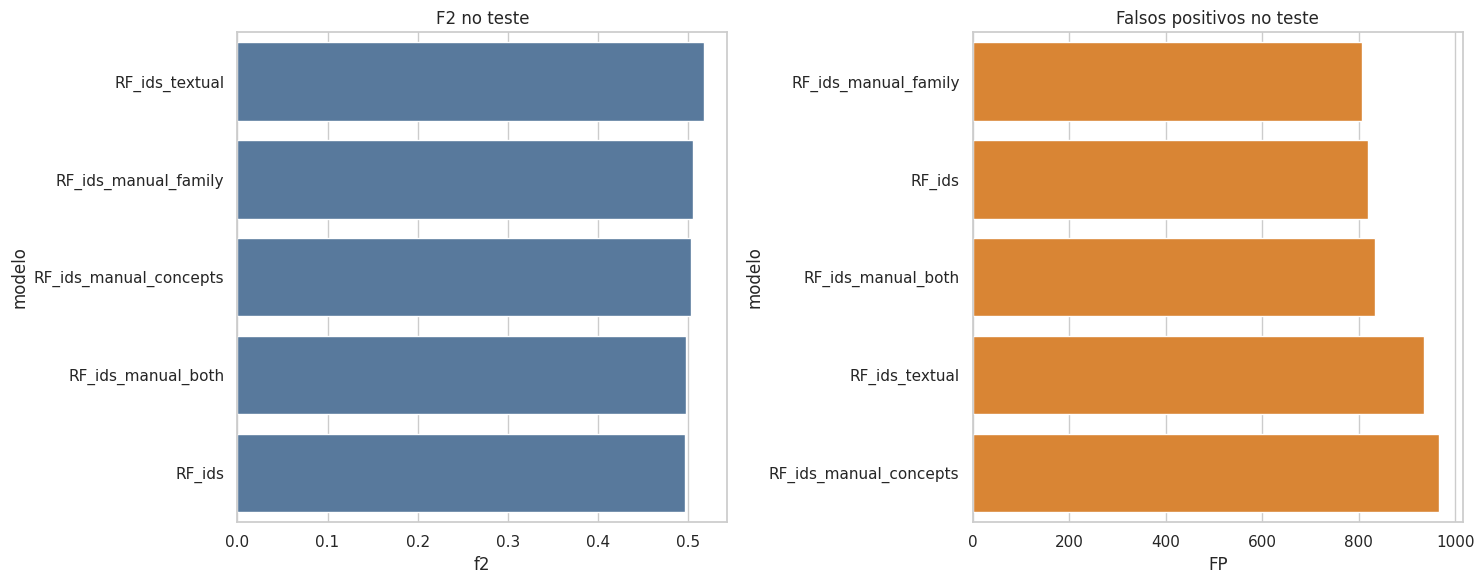

In [7]:
test_metrics = metrics[metrics["split"] == "teste"].copy()
display(
    test_metrics[[
        "modelo", "threshold", "pr_auc", "precision", "recall", "f2",
        "predicoes_positivas", "TP", "FP", "FN", "TN"
    ]].sort_values("f2", ascending=False)
)

type_rows = []
for (model_name, tipo), part in predictions.groupby(["modelo", "Tipo"], dropna=False):
    y = part["target"].to_numpy()
    pred = part["predito"].to_numpy()
    type_rows.append({
        "modelo": model_name,
        "Tipo": tipo,
        "amostras": len(part),
        "positivas": int(y.sum()),
        "predicoes_positivas": int(pred.sum()),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f2": fbeta_score(y, pred, beta=2, zero_division=0),
        "FP": int(((y == 0) & (pred == 1)).sum()),
        "FN": int(((y == 1) & (pred == 0)).sum()),
    })
type_metrics = pd.DataFrame(type_rows)
display(type_metrics.sort_values(["Tipo", "f2"], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=test_metrics.sort_values("f2", ascending=False), x="f2", y="modelo", ax=axes[0], color="#4C78A8")
axes[0].set(title="F2 no teste")
sns.barplot(data=test_metrics.sort_values("FP", ascending=True), x="FP", y="modelo", ax=axes[1], color="#F58518")
axes[1].set(title="Falsos positivos no teste")
plt.tight_layout()
plt.show()

## 6. Leitura auditada

Critérios:

- se o mapa manual reduzir falsos positivos mantendo recall próximo ao modelo textual, ele merece
  refinamento;
- se piorar F2 ou recall, manter conceitos textuais por enquanto;
- se escavadeiras continuarem com recall zero, o problema segue sendo target escasso, não apenas
  representação de alarmes;
- qualquer ganho aqui é exploratório, pois o mapa foi orientado por análise pós-teste.